In [1]:
import numpy as np #linear Algebra
import pandas as pd #data processing csv file
import matplotlib.pyplot as plt #plot
from builtins import list
import matplotlib
matplotlib.style.use('ggplot')
import seaborn as sns
import datetime
import calendar
import matplotlib.pyplot as plt


In [2]:
uber_df=pd.read_csv('C:/Users/Mansi/UberProject/UberDataset.csv')
print(uber_df.shape)
data = pd.read_csv('C:/Users/Mansi/UberProject/UberDataset.csv')


(1156, 7)


In [3]:
uber_df.head()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21.11,01-01-2016 21.17,Business,Fort Pierce,Fort Pierce,5.1,Meal-Entertain
1,01-02-2016 1.25,01-02-2016 1.37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20.25,01-02-2016 20.38,Business,Fort Pierce,Fort Pierce,4.8,Errand-Supplies
3,01-05-2016 17.31,01-05-2016 17.45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14.42,01-06-2016 15.49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [4]:
uber_df.tail()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
1151,12-31-2016 13:24,12-31-2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12-31-2016 15:03,12-31-2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12-31-2016 21:32,12-31-2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12-31-2016 22:08,12-31-2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site
1155,Totals,NaN,NaN,NaN,NaN,12204.7,NaN


In [5]:
#remove unnecessary data.
uber_df = uber_df[:-1] #remove the last row.

In [6]:
uber_df.shape 

(1155, 7)

In [8]:
uber_df.tail()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
1150,12-31-2016 1:07,12-31-2016 1:14,Business,Kar?chi,Kar?chi,0.7,Meeting
1151,12-31-2016 13:24,12-31-2016 13:42,Business,Kar?chi,Unknown Location,3.9,Temporary Site
1152,12-31-2016 15:03,12-31-2016 15:38,Business,Unknown Location,Unknown Location,16.2,Meeting
1153,12-31-2016 21:32,12-31-2016 21:50,Business,Katunayake,Gampaha,6.4,Temporary Site
1154,12-31-2016 22:08,12-31-2016 23:51,Business,Gampaha,Ilukwatta,48.2,Temporary Site


In [9]:
uber_df.isnull().sum()
#empty values which is not filled.

START_DATE      0
END_DATE        0
CATEGORY        0
START           0
STOP            0
MILES           0
PURPOSE       502
dtype: int64

<Axes: >

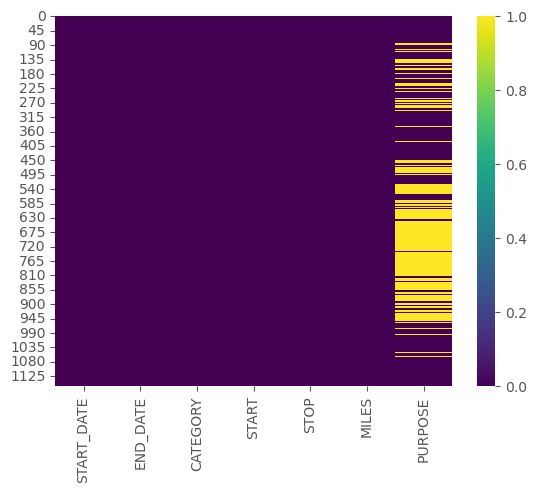

In [9]:
sns.heatmap(data.isnull(),cmap="viridis")#give scaling of 1500 rows and give intrepretation at which instance "Purpose" is null

<Axes: >

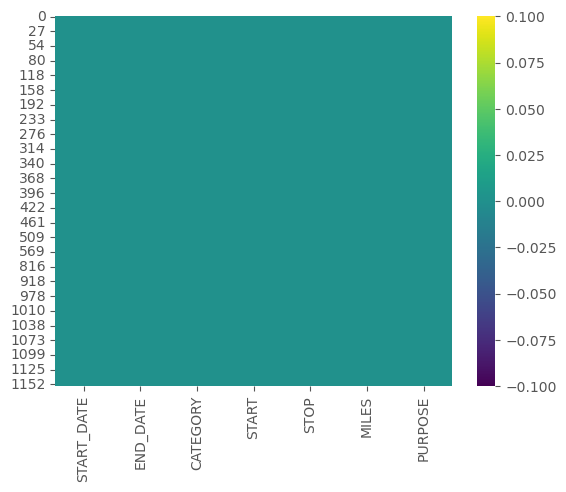

In [10]:
data=data.dropna()    #drop the null values.
sns.heatmap(data.isnull(),cmap="viridis")#now we don't have any null values.

In [11]:
# Count of rows before removing rows with NaT values
count_before = len(data)

# Convert START_DATE and END_DATE columns to datetime
data['START_DATE'] = pd.to_datetime(data['START_DATE'], errors='coerce', infer_datetime_format=True) #this function will transform our data from "MM/DD/YYYY" to "YYYY-MM-DD" format.
data['END_DATE'] = pd.to_datetime(data['END_DATE'], errors='coerce', infer_datetime_format=True)#Transformation for two columns.

# Remove rows with NaT values in START_DATE and END_DATE columns
data = data[pd.notna(data['START_DATE']) & pd.notna(data['END_DATE'])]

# Count of rows after removing rows with NaT values
count_after = len(data)

# Print the DataFrame after removing rows with NaT values
print("DataFrame after removing rows with NaT values:")
print(data)

# Print the count of rows before and after removing rows with NaT values
print("\nCount of rows before removing:", count_before)
print("Count of rows after removing:", count_after)

C:\Users\Mansi\AppData\Local\Temp\ipykernel_16756\4107635412.py:5: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data['START_DATE'] = pd.to_datetime(data['START_DATE'], errors='coerce', infer_datetime_format=True) #this function will transform our data from "MM/DD/YYYY" to "YYYY-MM-DD" format.
C:\Users\Mansi\AppData\Local\Temp\ipykernel_16756\4107635412.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['START_DATE'] = pd.to_datetime(data['START_DATE'], errors='coerce', infer_datetime_format=True) #this function will transform our data from "MM/DD/YYYY" to "YYYY-MM-DD" format.
C:\Users\Mansi\AppData\Local\Temp\ipykernel_16756\4

DataFrame after removing rows with NaT values:
              START_DATE            END_DATE  CATEGORY             START  \
23   2016-01-13 13:54:00 2016-01-13 14:07:00  Business          Downtown   
24   2016-01-13 15:00:00 2016-01-13 15:28:00  Business           Gulfton   
25   2016-01-14 16:29:00 2016-01-14 17:05:00  Business           Houston   
26   2016-01-14 21:39:00 2016-01-14 21:45:00  Business        Eagan Park   
27   2016-01-15 00:41:00 2016-01-15 01:01:00  Business       Morrisville   
...                  ...                 ...       ...               ...   
1150 2016-12-31 01:07:00 2016-12-31 01:14:00  Business           Kar?chi   
1151 2016-12-31 13:24:00 2016-12-31 13:42:00  Business           Kar?chi   
1152 2016-12-31 15:03:00 2016-12-31 15:38:00  Business  Unknown Location   
1153 2016-12-31 21:32:00 2016-12-31 21:50:00  Business        Katunayake   
1154 2016-12-31 22:08:00 2016-12-31 23:51:00  Business           Gampaha   

                  STOP  MILES          P

In [12]:
hour=[]
day=[]
dayofweek=[]
month=[]
weekday=[]               #array initalization
for x in data['START_DATE']:
    hour.append(x.hour)
    day.append(x.day)
    dayofweek.append(x.dayofweek)                       #conversion.
    month.append(x.month)
    weekday.append(calendar.day_name[dayofweek[-1]])    #To list Day on the Date according to index.
data['HOUR']=hour
data['DAY']=day
data['DAY_OF_WEEK']=dayofweek
data['MONTH']=month
data['WEEKDAY']=weekday     #assigning variables.

In [13]:
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,HOUR,DAY,DAY_OF_WEEK,MONTH,WEEKDAY
23,2016-01-13 13:54:00,2016-01-13 14:07:00,Business,Downtown,Gulfton,11.2,Meeting,13,13,2,1,Wednesday
24,2016-01-13 15:00:00,2016-01-13 15:28:00,Business,Gulfton,Downtown,11.8,Meeting,15,13,2,1,Wednesday
25,2016-01-14 16:29:00,2016-01-14 17:05:00,Business,Houston,Houston,21.9,Customer Visit,16,14,3,1,Thursday
26,2016-01-14 21:39:00,2016-01-14 21:45:00,Business,Eagan Park,Jamestown Court,3.9,Errand-Supplies,21,14,3,1,Thursday
27,2016-01-15 00:41:00,2016-01-15 01:01:00,Business,Morrisville,Cary,8.0,Errand-Supplies,0,15,4,1,Friday


In [14]:
time=[]
data['TRAVELLING_TIME']=data['END_DATE']-data['START_DATE']   #Travelling Time.
for i in data['TRAVELLING_TIME']:
    time.append(i.seconds/60)        #minute conversion.
data['TRAVELLING_TIME']=time
data.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,HOUR,DAY,DAY_OF_WEEK,MONTH,WEEKDAY,TRAVELLING_TIME
23,2016-01-13 13:54:00,2016-01-13 14:07:00,Business,Downtown,Gulfton,11.2,Meeting,13,13,2,1,Wednesday,13.0
24,2016-01-13 15:00:00,2016-01-13 15:28:00,Business,Gulfton,Downtown,11.8,Meeting,15,13,2,1,Wednesday,28.0
25,2016-01-14 16:29:00,2016-01-14 17:05:00,Business,Houston,Houston,21.9,Customer Visit,16,14,3,1,Thursday,36.0
26,2016-01-14 21:39:00,2016-01-14 21:45:00,Business,Eagan Park,Jamestown Court,3.9,Errand-Supplies,21,14,3,1,Thursday,6.0
27,2016-01-15 00:41:00,2016-01-15 01:01:00,Business,Morrisville,Cary,8.0,Errand-Supplies,0,15,4,1,Friday,20.0


In [15]:
data['TRAVELLING_TIME']=data['TRAVELLING_TIME']/60
data['SPEED']=data['MILES']/data['TRAVELLING_TIME']   #miles per hour 
data.head()


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE,HOUR,DAY,DAY_OF_WEEK,MONTH,WEEKDAY,TRAVELLING_TIME,SPEED
23,2016-01-13 13:54:00,2016-01-13 14:07:00,Business,Downtown,Gulfton,11.2,Meeting,13,13,2,1,Wednesday,0.216667,51.692308
24,2016-01-13 15:00:00,2016-01-13 15:28:00,Business,Gulfton,Downtown,11.8,Meeting,15,13,2,1,Wednesday,0.466667,25.285714
25,2016-01-14 16:29:00,2016-01-14 17:05:00,Business,Houston,Houston,21.9,Customer Visit,16,14,3,1,Thursday,0.600000,36.500000
26,2016-01-14 21:39:00,2016-01-14 21:45:00,Business,Eagan Park,Jamestown Court,3.9,Errand-Supplies,21,14,3,1,Thursday,0.100000,39.000000
27,2016-01-15 00:41:00,2016-01-15 01:01:00,Business,Morrisville,Cary,8.0,Errand-Supplies,0,15,4,1,Friday,0.333333,24.000000


<Axes: xlabel='CATEGORY', ylabel='count'>

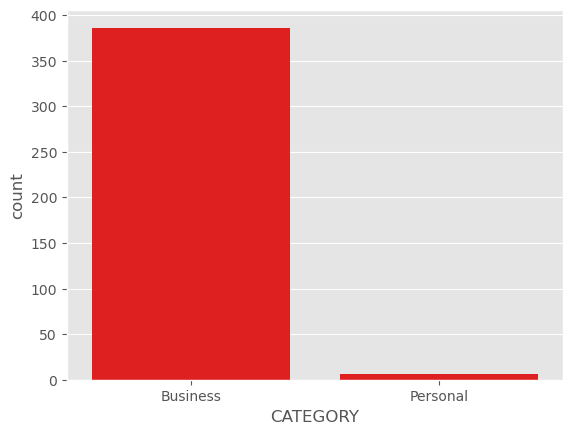

In [16]:
sns.countplot(x='CATEGORY',data=data,color="red") #intrpeting that Uber is used for buisness class more than personal.

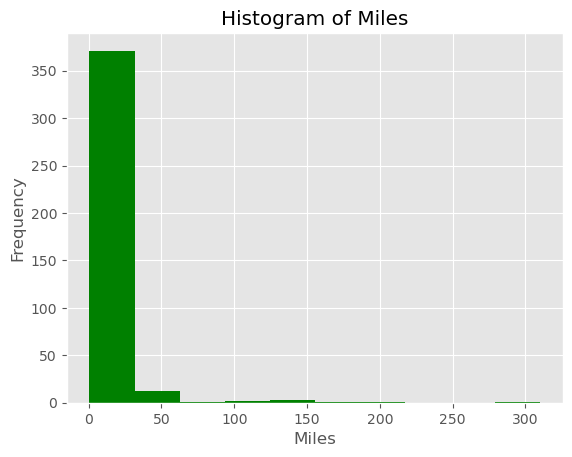

In [17]:
data['MILES'].plot.hist(color="green")
plt.xlabel('Miles')
plt.ylabel('Frequency')
plt.title('Histogram of Miles')
plt.show()
#ususally used for short distance commute rather than long distance.


<Axes: xlabel='PURPOSE'>

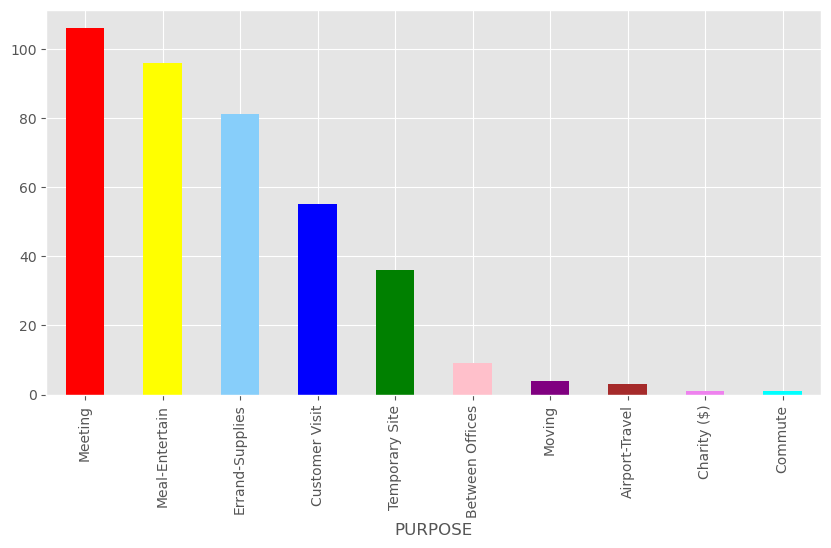

In [18]:
colors = ["red", "yellow", "lightskyblue", "blue", "green", "pink", "purple","Brown","Violet","Cyan"]
data['PURPOSE'].value_counts().plot(kind='bar',figsize=(10,5),color=colors) #which purpose is most used.

In [19]:
temp_df=data['PURPOSE'].value_counts()
temp_df=temp_df.to_frame()
temp_df.reset_index(inplace=True)
temp_df.columns=['Purpose','Count']
temp_df

,Purpose,Count
0,Meeting,106
1,Meal-Entertain,96
2,Errand-Supplies,81
3,Customer Visit,55
4,Temporary Site,36
5,Between Offices,9
6,Moving,4
7,Airport-Travel,3
8,Charity ($),1
9,Commute,1


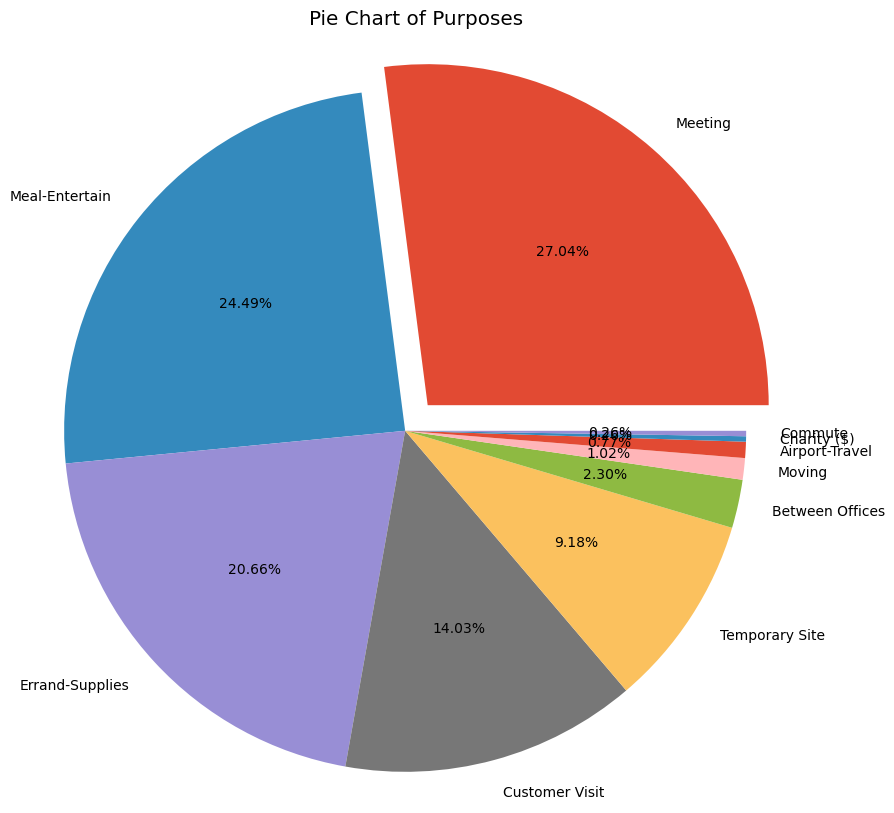

In [20]:
explode = (0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0)
plt.pie(temp_df['Count'], explode=explode, labels=temp_df['Purpose'], autopct='%1.2f%%')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.title('Pie Chart of Purposes')
plt.show()


<Axes: xlabel='PURPOSE'>

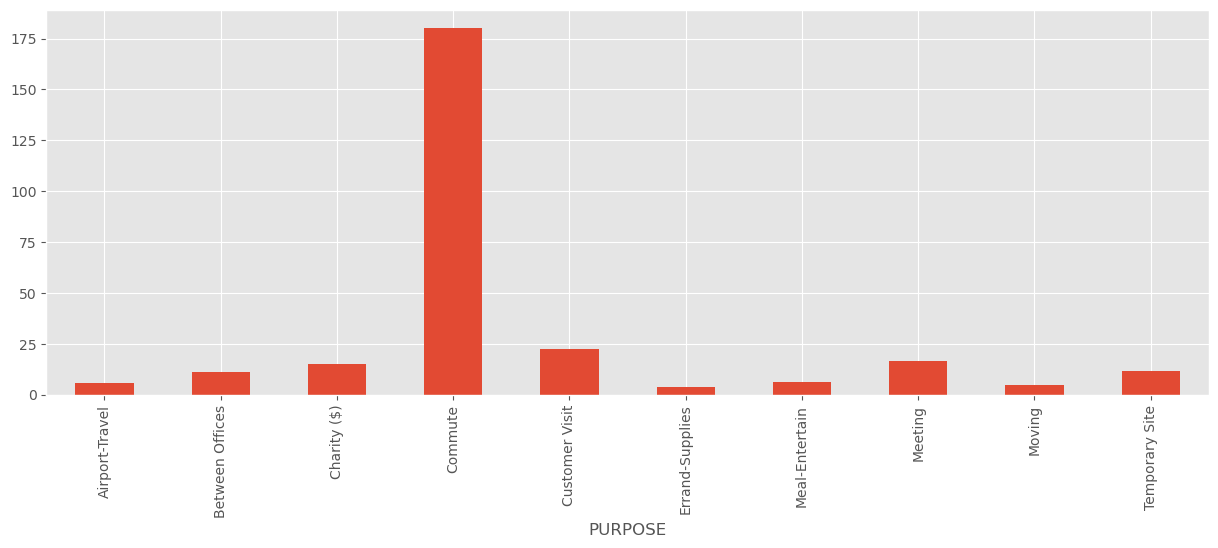

In [21]:
data.groupby('PURPOSE')['MILES'].mean().plot(kind='bar',figsize=(15,5))

In [22]:
temp_df=data['HOUR'].value_counts()
temp_df=temp_df.to_frame()
temp_df.reset_index(inplace=True)
temp_df.columns=['Hour','Count']
temp_df

,Hour,Count
0,13,34
1,17,33
2,11,32
3,15,32
4,18,32
5,14,30
6,10,25
7,16,25
8,12,24
9,20,23


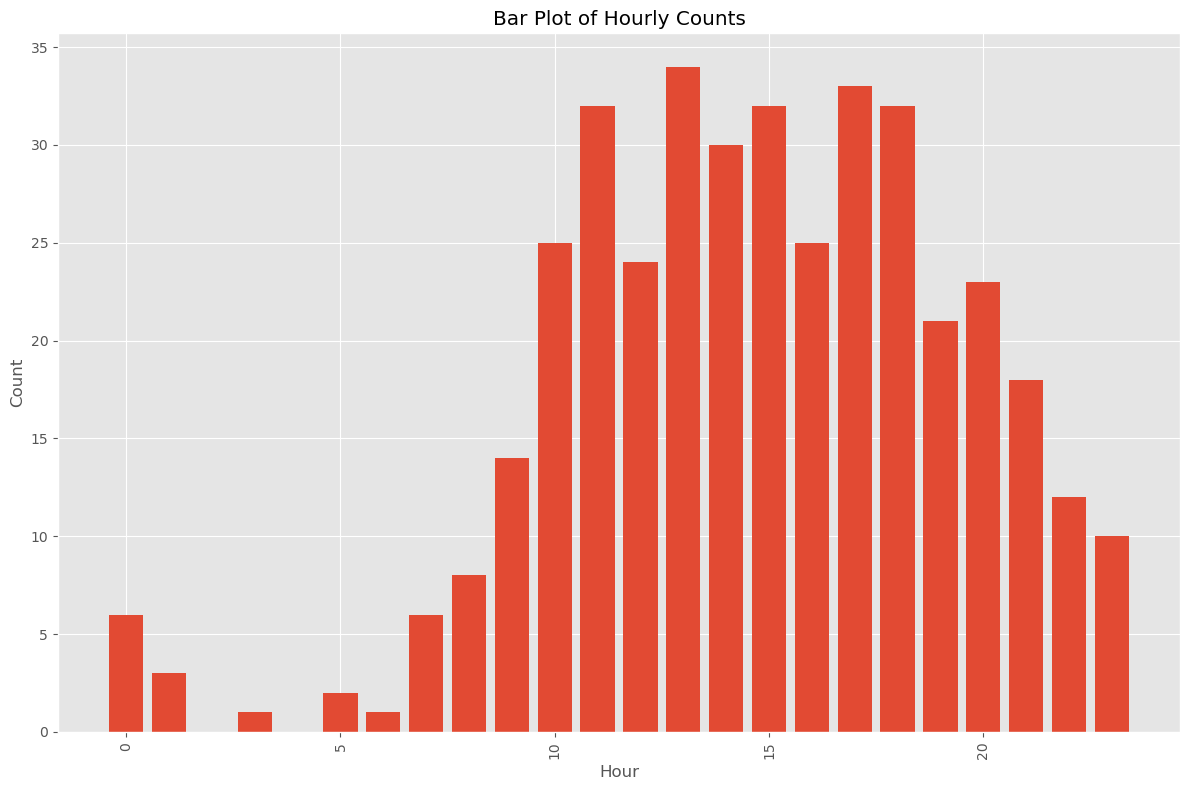

In [23]:
plt.figure(figsize=(12, 8))
ax = plt.bar(temp_df['Hour'], temp_df['Count'])
plt.xlabel("Hour")
plt.ylabel("Count")
plt.title("Bar Plot of Hourly Counts")
plt.xticks(rotation=90)  # Rotate x-axis labels by 90 degrees
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))  # Format y-axis labels with commas
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

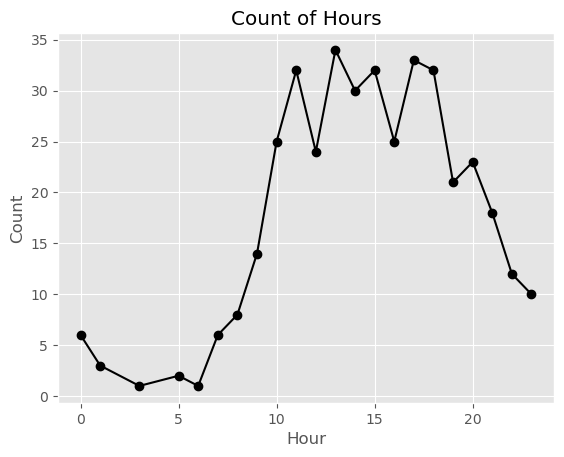

In [24]:
temp_df = data['HOUR'].value_counts().to_frame().reset_index()
temp_df.columns = ['Hour', 'Count']
ts = temp_df.sort_values('Hour', ascending=True)

plt.plot(ts['Hour'], ts['Count'], '-ok')
plt.xlabel('Hour')
plt.ylabel('Count')
plt.title('Count of Hours')
plt.show()

<Axes: xlabel='WEEKDAY'>

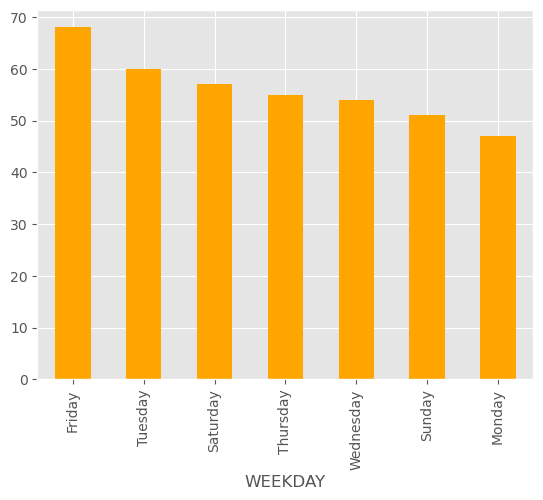

In [25]:
data['WEEKDAY'].value_counts().plot(kind='bar',color='orange')   #which day he requires more to ride.

<Axes: xlabel='DAY'>

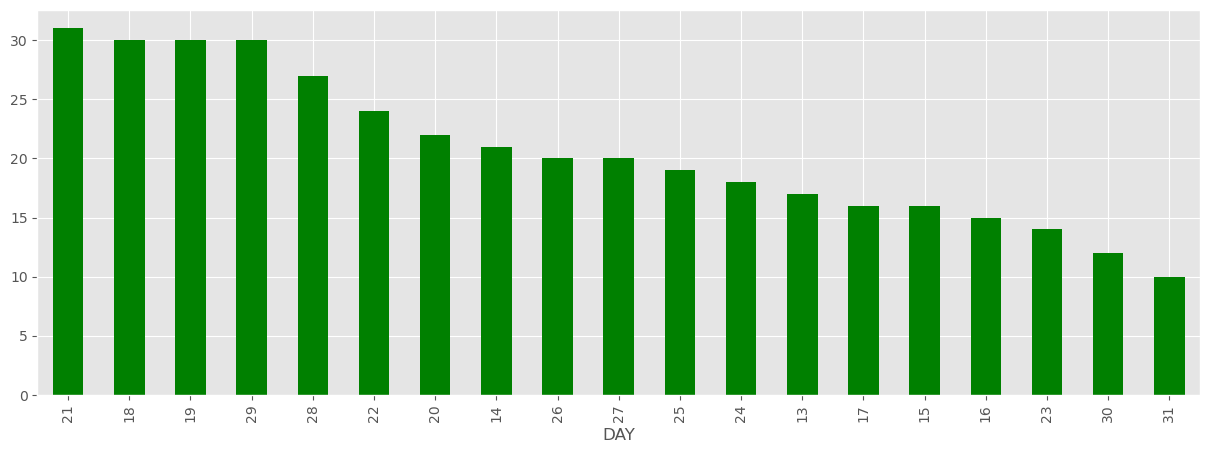

In [26]:
data['DAY'].value_counts().plot(kind='bar',figsize=(15,5),color='green')    #which date he travels more.

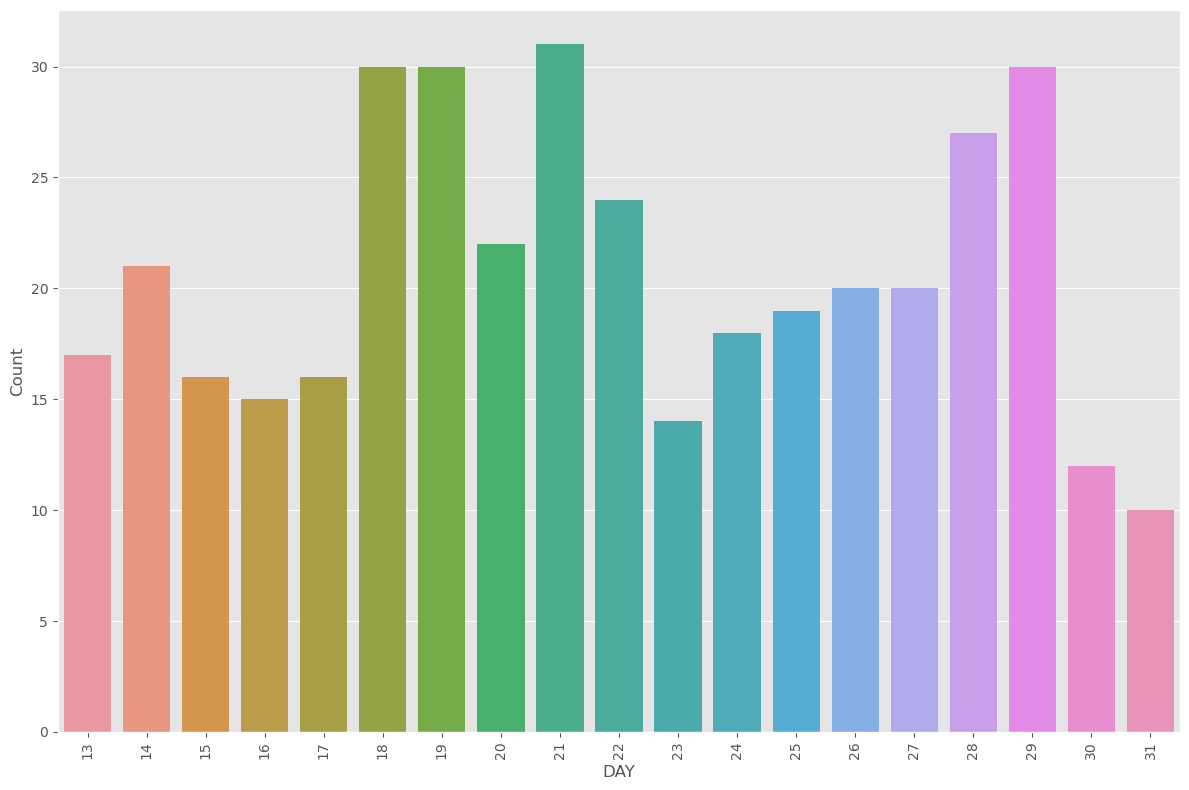

In [27]:
temp_df=data['DAY'].value_counts()
temp_df=temp_df.to_frame()
temp_df.reset_index(inplace=True)
temp_df.columns=['DAY','Count']
plt.figure(figsize=(12,8))
ax = sns.barplot(x="DAY", y= "Count",data=temp_df )
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
ax.set(xlabel="DAY", ylabel='Count')
for item in ax.get_xticklabels():
    item.set_rotation(90)
plt.tight_layout()

<Axes: xlabel='MONTH'>

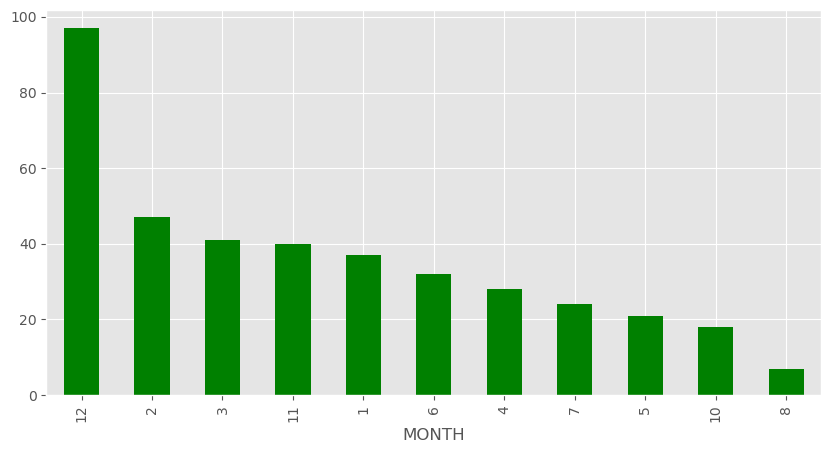

In [28]:
data['MONTH'].value_counts().plot(kind='bar',figsize=(10,5),color='green')   #which month he requires more.

<Axes: xlabel='START'>

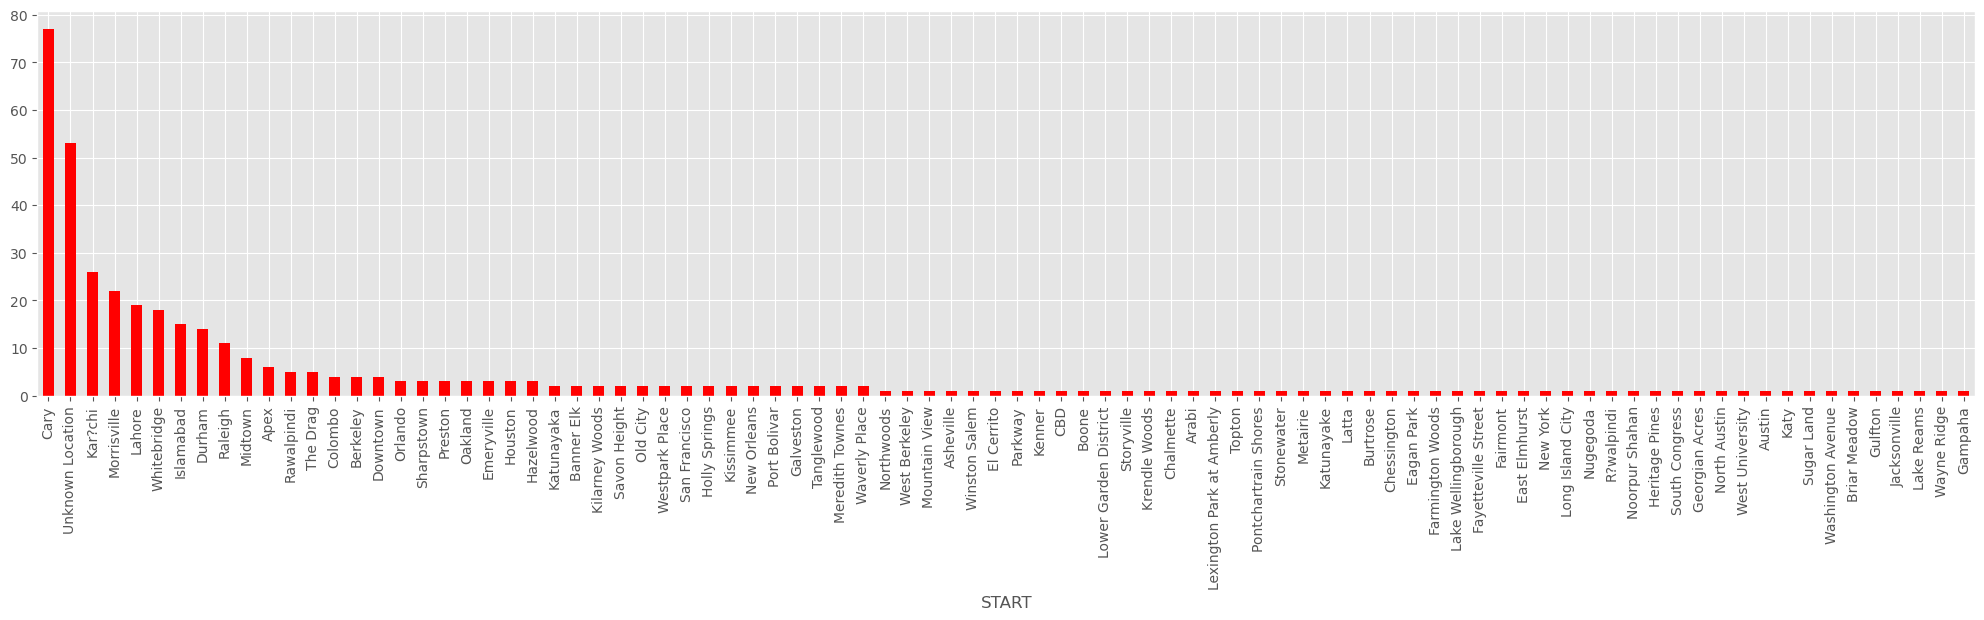

In [29]:
data['START'].value_counts().plot(kind='bar',figsize=(25,5),color='red') #which location he starts more.

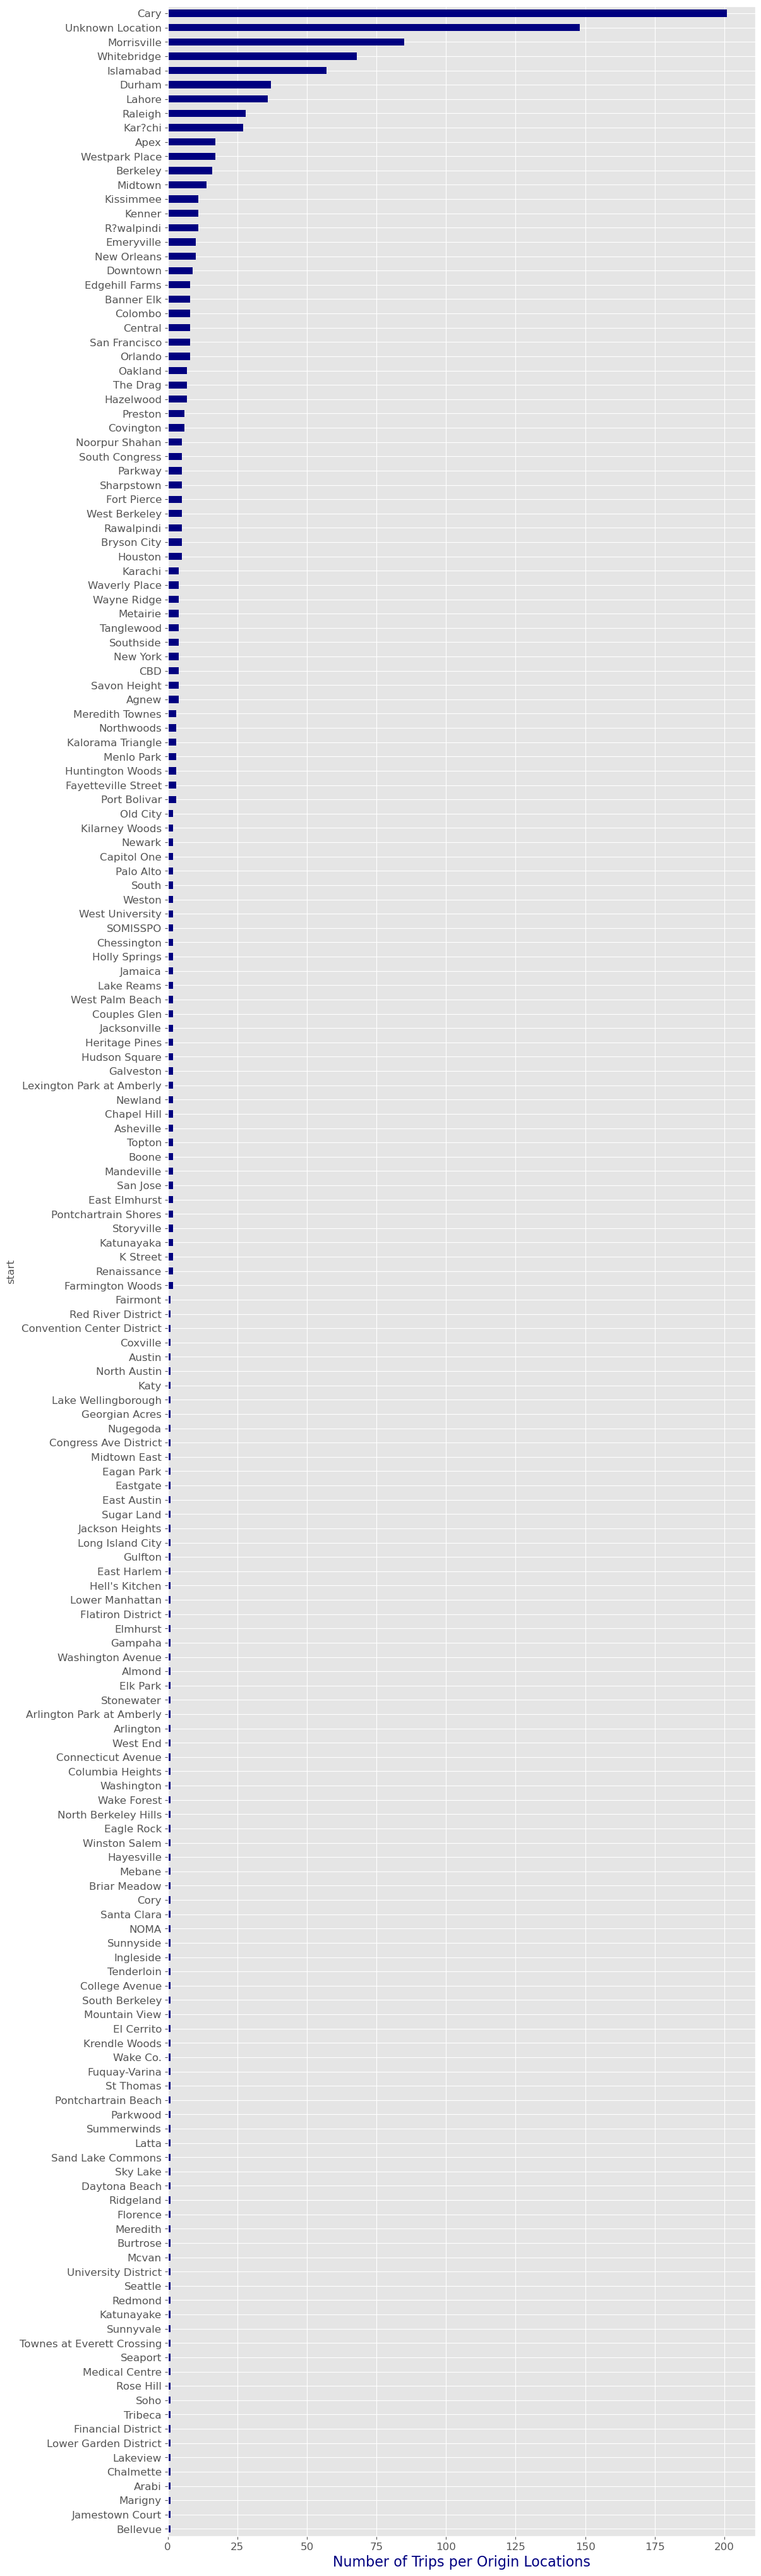

In [30]:
fig = plt.figure(figsize = (12,52))
new_df = pd.read_csv("C:/Users/Mansi/UberProject/UberDataset.csv")
new_df.columns=['sd','ed','cat','start','stop','M','prp']
ax1 = new_df.start.value_counts(ascending = True).plot(kind = 'barh', color = 'navy')

plt.tick_params(labelsize=12)
plt.xlabel('Number of Trips per Origin Locations', fontsize = 16, color='navy')

plt.show()